# Introduction


**File:** Notebook_to_build_graphics.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 10.03.2026
\
**Problem:** Here there are two:
 1) Plot $\psi(x)$
 2) Test our model for $M_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$

This code contains two short exercises. The first is just a sample of a run of our derivative grid code, which plots the IVP solutions for $\psi(x)$ The second is a short Monte Carlo test of our model for $M_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$, which contains both visual and numerical analysis.

# Derivative Grids

This is the code used for building the derivative grid graphs with the deriv_grid class of my library.

In [ ]:
#--LIBRARIES--------

#numerics
import numpy as np
import eelib

#--CODE--

# set parameters
# note that k, B, and R are percents here, mu is not as its scale is unknown
k = 0.625
R = 0.8
B = 0.5
mu = 1.0e-7

n_g = 4

pr = 1000
n = 2

loopl = eelib.deriv_grid(R, B, k, mu, grid_size=n_g)
loopl.derivGrid()


# --- PLOTTING FOR GRIDS ---
for i in range(n_g):
    for j in range(n_g):
        loopl.plot_abs(i,j,k,R,B,mu,n)
        loopl.plot_real(i,j,k,R,B,mu,n)

# Test of Slow Oscillation Wavenumber Model

This is code to visually and numerically test the fit of my slow oscillation model. The model is not perfect, but good enough.

In [1]:
import eelib
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as mtc
from sklearn.metrics import root_mean_squared_error

In [2]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-6

n_mc = 1000

b_r  = (0.5, 1.0)  # B here is B*R
mu_r = (1.0e-8, 1.0e-6)    # 1.0e-8 to 1.0e-6
k_r = (0.1,0.9)


In [3]:
rms_ratio_graph = np.sqrt(1000) / np.sqrt(999)
rms_ratio_fin = np.sqrt(n_mc)/ np.sqrt(n_mc - 1)

In [4]:
#--CODE--

# Make the grid object
gridl = eelib.grid_slow_osc(R, B, dk, mu)

# Save our full solution
gridl.save_solution = True

# Make the grid
gridl.makeMCPoints(mu=mu_r, dk=k_r, B=b_r, num = n_mc)

# Run the grid
gridl.mcSlowOsc()

Begin grid build:  0.0
Number of periods to calculate: 1000
Done grid build:  44238.497473955154


In [5]:
import pickle
filename = 'grid203'

# Since this takes a while to run and is used for a while, it is best to save a copy of the data.
file = open(filename, 'ab')
pickle.dump(gridl, file)
file.close()

In [6]:
# First, declare which solution I am using
ii  = int(np.random.rand()*n_mc)
#if ii >= n_mc: ii = n_mc - 1 # just in case
sol = gridl.slow_osc_sol[ii]
#sol1 = gridl.slow_osc_sol_1[ii]

# Retrieve my fits for this function from the grid.
MM    = gridl.slow_osc_k[ii]
amp   = gridl.slow_osc_a[ii]
theta = gridl.slow_osc_th[ii]

# Predicted slow oscillation amplitude.
vt = gridl.val_table[ii] # mu, dk, B, R, A, k0, dr, di
MM2 = eelib.pred_slow_k(vt[6]+1j*vt[7], vt[0], vt[0], vt[2]*eelib.B_max, vt[3]*eelib.R_max, vt[4], vt[5]) #dpsi0, mu, dk, B, R, A = 1., k0=kFAu

# Pull the found solution from the sol variable.
t_list  = sol['t'][:-1]
y1_list = np.real(sol['y'][0][:-1])

# Estimated fit
y2_list = amp * np.sin(MM2 * (t_list) + theta)

# Fit to a sin using SciPy
y3_list = amp * np.sin(MM * t_list + theta)

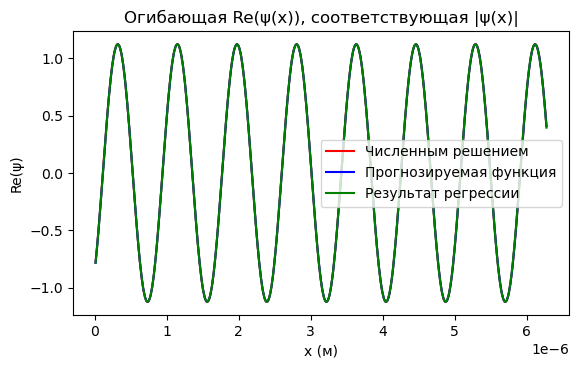

In [7]:
# And plot the results
fig, ax = plt.subplots()

ax.set_ylabel('Re(ψ)')
ax.set_xlabel('x (м)')
plt.title(f"Огибающая Re(ψ(x)), соответствующая |ψ(x)|")

line1, = ax.plot(t_list, y1_list, color = 'red', label = 'Численным решением')
line2, = ax.plot(t_list, y2_list, color = 'blue', label = 'Прогнозируемая функция')
line3, = ax.plot(t_list, y3_list, color = 'green', label = 'Результат регрессии')

ax.legend(handles=[line1,line2,line3])
ax.set_box_aspect(2.0/3.5)

plt.savefig("matchMivp007.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [8]:
print(root_mean_squared_error(y1_list, y2_list)/np.max(np.abs(y1_list)))
print(root_mean_squared_error(y1_list, y3_list)/np.max(np.abs(y1_list)))
print(root_mean_squared_error(y2_list, y3_list)/np.max(np.abs(y1_list)))

0.0033147167003855288
0.004066763311547634
0.006053850424594592


In [9]:
print(mtc.mean_absolute_percentage_error(y1_list, y2_list))
print(mtc.mean_absolute_percentage_error(y1_list, y3_list))
print(mtc.mean_absolute_percentage_error(y2_list, y3_list))

0.02778663340163995
0.029162889071744504
0.04903373207508232


In [10]:
print(mtc.r2_score(y1_list, y2_list))
print(mtc.r2_score(y1_list, y3_list))
print(mtc.r2_score(y2_list, y3_list))
#print(mtc.mean_absolute_percentage_error(y1_list, y2_list))
#print(mtc.mean_absolute_percentage_error(y1_list, y3_list))
#print(mtc.mean_absolute_percentage_error(y2_list, y3_list))

0.9999778795413538
0.999966703461368
0.9999260966883956


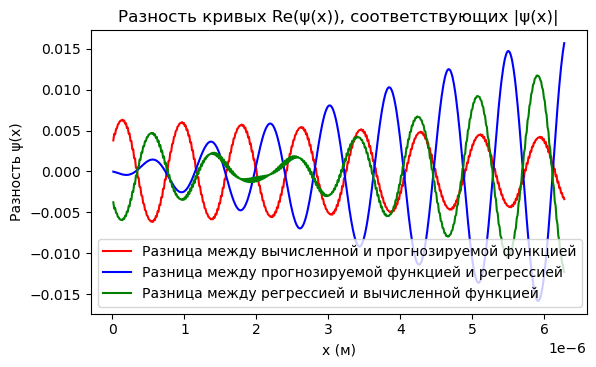

In [11]:
# Plot differences
fig, ax = plt.subplots()

ax.set_ylabel('Разность ψ(x)')
ax.set_xlabel('x (м)')
plt.title(f"Разность кривых Re(ψ(x)), соответствующих |ψ(x)|")

line1, = ax.plot(t_list, y1_list-y2_list, color = 'red', label = 'Разница между вычисленной и прогнозируемой функцией')
line2, = ax.plot(t_list, y2_list-y3_list, color = 'blue', label = 'Разница между прогнозируемой функцией и регрессией')
line3, = ax.plot(t_list, y3_list-y1_list, color = 'green', label = 'Разница между регрессией и вычисленной функцией')

ax.legend(handles=[line1,line2,line3])
ax.set_box_aspect(2.0/3.5)

plt.savefig("matchMivp008.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [12]:
np.abs(gridl.slow_osc_sol_1[ii]-gridl.slow_osc_sol[ii]['y'][0][-1])

0.00544977380658301

In [13]:
res = []
for i in range(n_mc):
    res.append(gridl.slow_osc_sol[i]['y'][0][-1])

In [14]:
# Print the differences
print(f"Estimated slow oscillation wave number: {MM2}")
print(f"Fit slow oscillation wave number: {MM}")
print("Maximum difference between regression fit and predicted fit:", np.max(y3_list-y2_list))
print("Maximum difference between numerical solution and predicted fit:", np.max(y1_list-y2_list))
print("Maximum difference between numerical solution and regression fit:", np.max(y1_list-y3_list))

Estimated slow oscillation wave number: 7585841.389161886
Fit slow oscillation wave number: 7588226.169172343
Maximum difference between regression fit and predicted fit: 0.015811153560285077
Maximum difference between numerical solution and predicted fit: 0.006322642127266825
Maximum difference between numerical solution and regression fit: 0.012291917063104452


In [15]:
# Now for the rest of the numbers
max_arr = np.zeros((n_mc,3))
ave_arr = np.zeros((n_mc,3))
std_arr = np.zeros((n_mc,3))
rmse_arr = np.zeros((n_mc,3))
mape_arr = np.zeros((n_mc,3))
r2_arr = np.zeros((n_mc,3))
arr_wn = np.zeros((n_mc,2))
arr_fp = np.zeros((n_mc,2), dtype="complex")
arr_max = np.zeros(n_mc)
for ii in range(n_mc):
    # First, declare which solution I am using
    sol = gridl.slow_osc_sol[ii]

    # Retrieve my fits for this function from the grid.
    MM    = gridl.slow_osc_k[ii]
    amp   = gridl.slow_osc_a[ii]
    theta = gridl.slow_osc_th[ii]

    # Predicted slow oscillation amplitude.
    vt = gridl.val_table[ii] # mu, dk, B, R, A, k0, dr, di
    MM2 = eelib.pred_slow_k(vt[6]+1j*vt[7], vt[0], vt[0], vt[2]*eelib.B_max, vt[3]*eelib.R_max, vt[4], vt[5]) #dpsi0, mu, dk, B, R, A = 1., k0=kFAu

    arr_wn[ii] = [MM, MM2]

    # Pull the found solution from the sol variable.
    t_list  = sol['t'][:-1]
    y1_list = np.real(sol['y'][0][:-1])

    # Estimated fit
    y2_list = amp * np.sin(MM2 * (t_list) + theta)

    # Fit to a sin using SciPy
    y3_list = amp * np.sin(MM * t_list + theta)

    y_end = sol['y'][0][-1]
    arr_fp[ii] = [y_end, gridl.slow_osc_sol_1[ii]]
    arr_max[ii] = np.max(np.abs(y1_list))

    max_arr[ii, :] = [np.max(np.abs(y3_list-y2_list)), np.max(np.abs(y1_list-y2_list)), np.max(np.abs(y1_list-y3_list))]
    ave_arr[ii, :] = [np.average(y3_list-y2_list), np.average(y1_list-y2_list), np.average(y1_list-y3_list)]
    std_arr[ii, :] = [np.std(y3_list-y2_list), np.std(y1_list-y2_list), np.std(y1_list-y3_list)]
    rmse_arr[ii, :] = [mtc.root_mean_squared_error(y3_list,y2_list)/np.max(np.abs(y1_list)), mtc.root_mean_squared_error(y1_list,y2_list)/np.max(np.abs(y1_list)), mtc.root_mean_squared_error(y1_list,y3_list)/np.max(np.abs(y1_list))]
    mape_arr[ii, :] = [mtc.mean_absolute_percentage_error(y3_list,y2_list), mtc.mean_absolute_percentage_error(y1_list,y2_list), mtc.mean_absolute_percentage_error(y1_list,y3_list)]
    r2_arr[ii, :] = [mtc.r2_score(y3_list,y2_list), mtc.r2_score(y1_list,y2_list), mtc.r2_score(y1_list,y3_list)]

    # Print the differences
    print(f"Random solution {ii}")
    print(f"Estimated slow oscillation wave number: {MM2}")
    print(f"Fit slow oscillation wave number: {MM}")
    print("Maximum difference between regression fit and estimated fit:", max_arr[ii,0])
    print("Maximum difference between numerical solution and estimated fit:", max_arr[ii,1])
    print("Maximum difference between numerical solution and regression fit:", max_arr[ii,2])
    print("Average Diff: ", ave_arr[ii,:])
    print("Std: ", std_arr[ii,:])
    print("rmse: ", rmse_arr[ii,:])
    print("mape: ", mape_arr[ii,:])

    print("")

Random solution 0
Estimated slow oscillation wave number: 7331779.528177009
Fit slow oscillation wave number: 7337372.172741708
Maximum difference between regression fit and estimated fit: 0.06131869925331372
Maximum difference between numerical solution and estimated fit: 0.06491705773787401
Maximum difference between numerical solution and regression fit: 0.0045203713845454185
Average Diff:  [-0.00129564 -0.00143691 -0.00014127]
Std:  [0.02595876 0.02691392 0.00221589]
rmse:  [0.01445066 0.01498506 0.00123451]
mape:  [0.08408624 0.08566211 0.00352082]

Random solution 1
Estimated slow oscillation wave number: 7042513.568049851
Fit slow oscillation wave number: 7033658.712206222
Maximum difference between regression fit and estimated fit: 0.07877427383755425
Maximum difference between numerical solution and estimated fit: 0.08414625998322461
Maximum difference between numerical solution and regression fit: 0.00537198614567036
Average Diff:  [3.48611110e-04 4.26443867e-04 7.78327568e-0

In [41]:
print("curve rel rmse", np.sqrt(np.average(np.power(rmse_arr[:,1]/arr_max, 2))*(1000*1000)/(1000*1000-1)))
print("curve rmse", np.sqrt(np.average(np.power(rmse_arr[:,1], 2))))
print("m rmse", mtc.root_mean_squared_error(arr_wn[:,0], arr_wn[:,1]))
print("m rel rmse", np.sqrt(1000/999)*np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0], 2))))
print("fin point rmse", np.sqrt(np.average(np.power(np.abs(arr_fp[:,0]-arr_fp[:,1]),2))))
print("fin point rel rmse", np.sqrt(np.sum(np.power(np.abs(arr_fp[:,0]-arr_fp[:,1]), 2))/999))
print("")
print("curve min r2", np.min(r2_arr[:,1]))
print("curve ave r2", np.average(r2_arr[:,1]))
print("m r2", mtc.r2_score(arr_wn[:,0], arr_wn[:,1]))
print("")
print("curve max", np.max(max_arr[:,1]))
print("curve rel max", np.max(max_arr[:,1]/arr_max))
print("m max", np.max(np.abs((arr_wn[:,0]-arr_wn[:,1]))))
print("m rel max", np.max(np.abs((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0])))
print("fin max", np.max(np.abs(arr_fp[:,0]-arr_fp[:,1])))
print("fin rel max", np.max(np.abs(arr_fp[:,0]-arr_fp[:,1])))
print("")
print("curve mean", np.average(ave_arr[:,1]))
print("curve std", np.sqrt(np.average(np.power(std_arr[:,1],2))))
print("m mean", np.average(arr_wn[:,0]-arr_wn[:,1]))
print("m std", np.std(arr_wn[:,0]-arr_wn[:,1]))
print("fin mean", np.average(arr_fp[:,0]-arr_fp[:,1]))
print("fin std", np.std(arr_fp[:,0]-arr_fp[:,1]))
print("")
print("curve mape", np.average(mape_arr[:,1]))
print("m mape", mtc.mean_absolute_percentage_error(arr_wn[:,0], arr_wn[:,1]))
print("fin mape", np.average(np.abs(arr_fp[:,0]-arr_fp[:,1])/np.abs(arr_fp[:,0])))

curve rel rmse 0.01205339593965692
curve rmse 0.01636824598918691
m rmse 5931.930165576997
m rel rmse 0.0009599866273135146
fin point rmse 0.05598428467968685
fin point rel rmse 0.056012297833643865

curve min r2 0.9714558707166048
curve ave r2 0.9994622603838773
m r2 0.9999850386479426

curve max 0.3292065551161225
curve rel max 0.1902100049529247
m max 36734.2782148812
m rel max 0.0082478326188947
fin max 0.20789355169854154
fin rel max 0.20789355169854154

curve mean -4.466993242462874e-05
curve std 0.02386889431066636
m mean 142.419969061621
m std 5930.220235513588
fin mean (0.0019450822390869248-0.0005798420920504179j)
fin std 0.0559474804555817

curve mape 0.19845083425240004
m mape 0.0005971724976895324
fin mape 0.05180609900839184


# unneeded

In [16]:
np.sqrt(np.average(np.power(rmse_arr[:,1]/arr_max, 2))*(1000*200)/(1000*200-1))

0.012053420046545226

In [17]:
np.min(r2_arr[:,1])

0.9714558707166048

In [18]:
np.average(r2_arr[:,1])

0.9994622603838773

In [19]:
print(np.max(max_arr[:,0]), np.max(mape_arr[:,0]), np.max(rmse_arr[:,0]))

0.3889063753416215 6.619231168120354 0.09546995189006532


In [20]:
np.sqrt(np.average(np.power(rmse_arr[:,1], 2)))

0.01636824598918691

In [21]:
np.average(mape_arr[:,0])

0.11940382215768176

In [22]:
print(np.max(max_arr[:,1]), np.max(mape_arr[:,1]), np.max(rmse_arr[:,1]))

0.3292065551161225 64.53462016223556 0.11897067319069335


In [23]:
print(np.average(max_arr[:,1]), np.average(mape_arr[:,1]), np.average(rmse_arr[:,1]))

0.03506156626202964 0.19845083425240004 0.010899195529127912


In [24]:
print(np.average(max_arr[:,0]), np.average(mape_arr[:,0]), np.average(rmse_arr[:,0]))

0.03497603574331505 0.11940382215768176 0.010455522658212143


In [25]:
np.sqrt(np.average(np.power(rmse_arr[:,1], 2))), np.sqrt(np.sum(np.power(rmse_arr[:,1], 2))/199)

(0.01636824598918691, 0.03669235654679942)

In [26]:
mtc.root_mean_squared_error(arr_wn[:,0], arr_wn[:,1])

5931.930165576997

In [27]:
mtc.mean_absolute_percentage_error(arr_wn[:,0], arr_wn[:,1])

0.0005971724976895324

In [28]:
np.max(np.abs((arr_wn[:,0]-arr_wn[:,1]))), np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0], 2)))#*np.sqrt(200)/np.sqrt(199)

(36734.2782148812, 0.0009595065139414927)

In [29]:
np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1]), 2)))

5931.930165576997

In [30]:
np.max((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0])

0.0082478326188947

In [31]:
mtc.r2_score(arr_wn[:,0], arr_wn[:,1])

0.9999850386479426

In [32]:
np.mean(arr_wn[:,0]-arr_wn[:,1]), np.std(arr_wn[:,0]-arr_wn[:,1])

(142.419969061621, 5930.220235513588)